In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report


In [10]:
# defining img size and batches
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# reforming images for better training
train_datagen = ImageDataGenerator(
    rescale=1./255,             # pixel values from 0-255 to 0-1
    rotation_range=40,          # rotates the images randomly
    width_shift_range=0.2,      # shifts the img horizontally
    height_shift_range=0.2,     # shifts the img vertically
    shear_range=0.2,           
    zoom_range=0.2,             # used for zooming
    horizontal_flip=True,       # randomly flips the img horizontal
    fill_mode='nearest',       
    validation_split=0.2        # 20% of images kept for validation
)

# generator for validating the data
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator = val_datagen.flow_from_directory(
    "dogs",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",        
    shuffle=False               
)


# img for training data
train_generator = train_datagen.flow_from_directory(
    "dogs",                 
    target_size=IMG_SIZE,       
    batch_size=BATCH_SIZE,      
    class_mode="categorical",  
    subset="training"           
)

NUM_CLASSES = train_generator.num_classes
print(f"\n✅ Found {train_generator.samples} images for training.")
print(f"✅ Found {validation_generator.samples} images for validation.")
print(f"✅ Found {NUM_CLASSES} classes (breeds).")

Found 4072 images belonging to 120 classes.
Found 16508 images belonging to 120 classes.

✅ Found 16508 images for training.
✅ Found 4072 images for validation.
✅ Found 120 classes (breeds).


In [11]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False,           
    weights='imagenet'
)

# 2. Freeze the layers of the base model so we don't ruin their learned weights
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x) # A better layer than Flatten for this task
x = Dense(512, activation='relu')(x) # more neurons for better learning
x = Dropout(0.5)(x)             # dropout - prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # final output layer

# 4. Combine into the final model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built successfully. Summary:")
model.summary()


✅ Model built successfully. Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,975,416 (11.35 MB)

 Trainable params: 717,432 (2.74 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# defining the number of steps per epoch
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

# training the model
history = model.fit(
    train_generator,
    epochs=15, # you can increase the no. for better accuracy
    validation_data=validation_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps
)

print("\n✅ Training finished.")

Epoch 1/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 843s 2s/step - accuracy: 0.3557 - loss: 2.6053 - val_accuracy: 0.6767 - val_loss: 1.0610
Epoch 2/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 154s 297ms/step - accuracy: 0.4375 - loss: 2.0670 - val_accuracy: 0.6791 - val_loss: 1.0597
Epoch 3/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 799s 2s/step - accuracy: 0.5134 - loss: 1.7711 - val_accuracy: 0.7116 - val_loss: 0.9673
Epoch 4/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 139s 268ms/step - accuracy: 0.5000 - loss: 1.4271 - val_accuracy: 0.7114 - val_loss: 0.9663
Epoch 5/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 835s 2s/step - accuracy: 0.5424 - loss: 1.6370 - val_accuracy: 0.7158 - val_loss: 0.9262
Epoch 6/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 145s 281ms/step - accuracy: 0.5938 - loss: 1.7528 - val_accuracy: 0.7158 - val_loss: 0.9246
Epoch 7/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 814s 2s/step - accuracy: 0.5549 - loss: 1.5883 - val_accuracy: 0.7242 - val_loss: 0.9007
Epoch 8/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 143s 276ms/step - accuracy: 0.4062 - loss: 2.743

In [13]:
print("\nFinal Evaluation on Validation Set")
loss, accuracy = model.evaluate(validation_generator, steps=validation_steps, verbose=1)
print(f"✅ Final Validation Loss: {loss:.4f}")
print(f"✅ Final Validation Accuracy: {accuracy*100:.2f}%")


Final Evaluation on Validation Set
127/127 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.7352 - loss: 0.8661
✅ Final Validation Loss: 0.8661
✅ Final Validation Accuracy: 73.52%


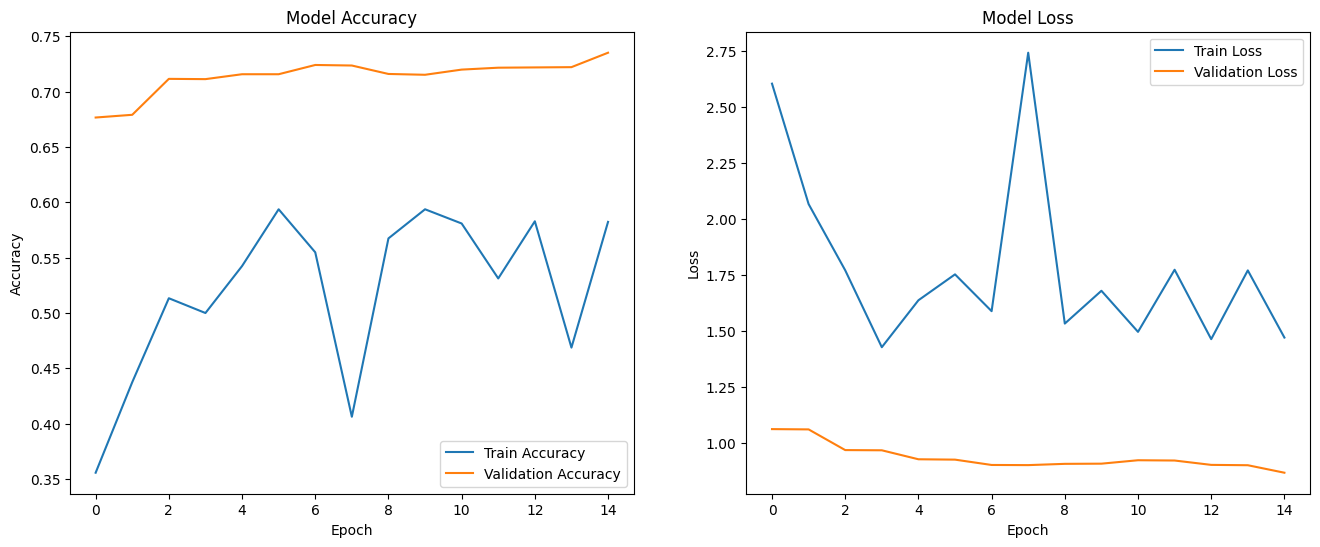


Generating predictions for the validation set
128/128 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step

precision, recall and f1-score of each breed
                                precision    recall  f1-score   support

                  Afghan_hound       0.70      0.89      0.79        47
           African_hunting_dog       0.80      0.97      0.88        33
                      Airedale       0.85      0.82      0.84        40
American_Staffordshire_terrier       0.53      0.62      0.57        32
                   Appenzeller       0.77      0.33      0.47        30
            Australian_terrier       0.73      0.77      0.75        39
            Bedlington_terrier       0.97      0.92      0.94        36
          Bernese_mountain_dog       0.89      0.93      0.91        43
              Blenheim_spaniel       0.85      0.76      0.80        37
                 Border_collie       0.70      0.77      0.73        30
                Border_terrier       0.93      0.74      0.82        34


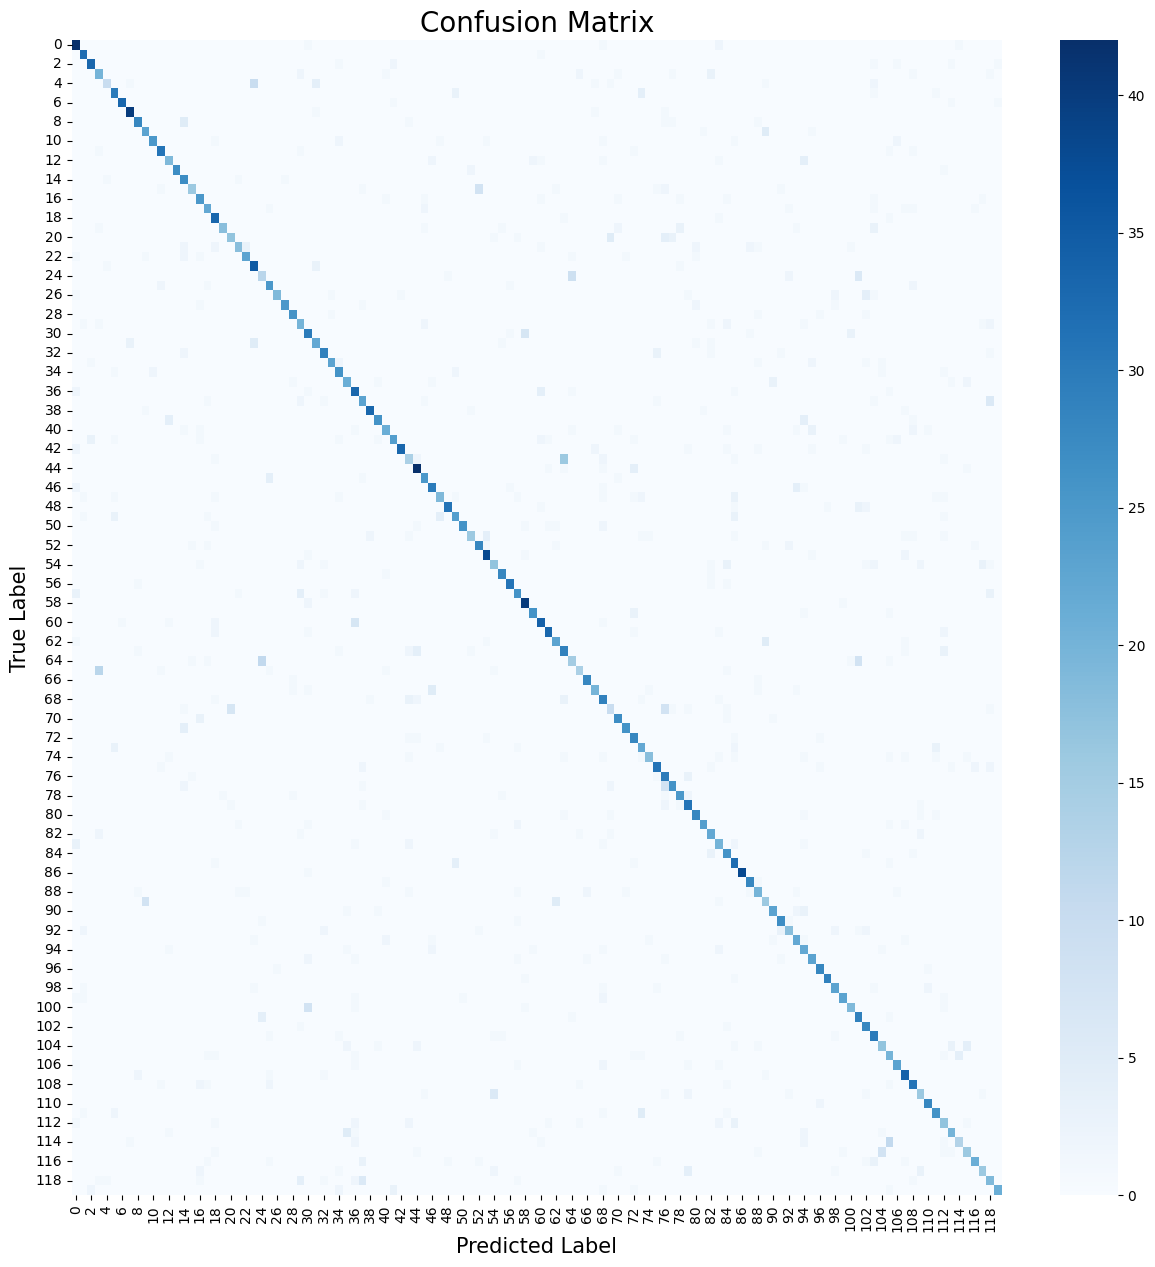

In [19]:
# accuracy and loss
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.show()

plot_history(history)

print("\nGenerating predictions for the validation set")
y_true = validation_generator.classes
Y_pred_probs = model.predict(validation_generator, steps=(validation_generator.samples // BATCH_SIZE) + 1)
y_pred = np.argmax(Y_pred_probs, axis=1)

print("\nprecision, recall and f1-score of each breed")
class_names = list(validation_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print("\nGenerating Confusion Matrix")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=False, cmap="Blues", cbar=True)
plt.title("Confusion Matrix", fontsize=20)
plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.show()


128/128 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step


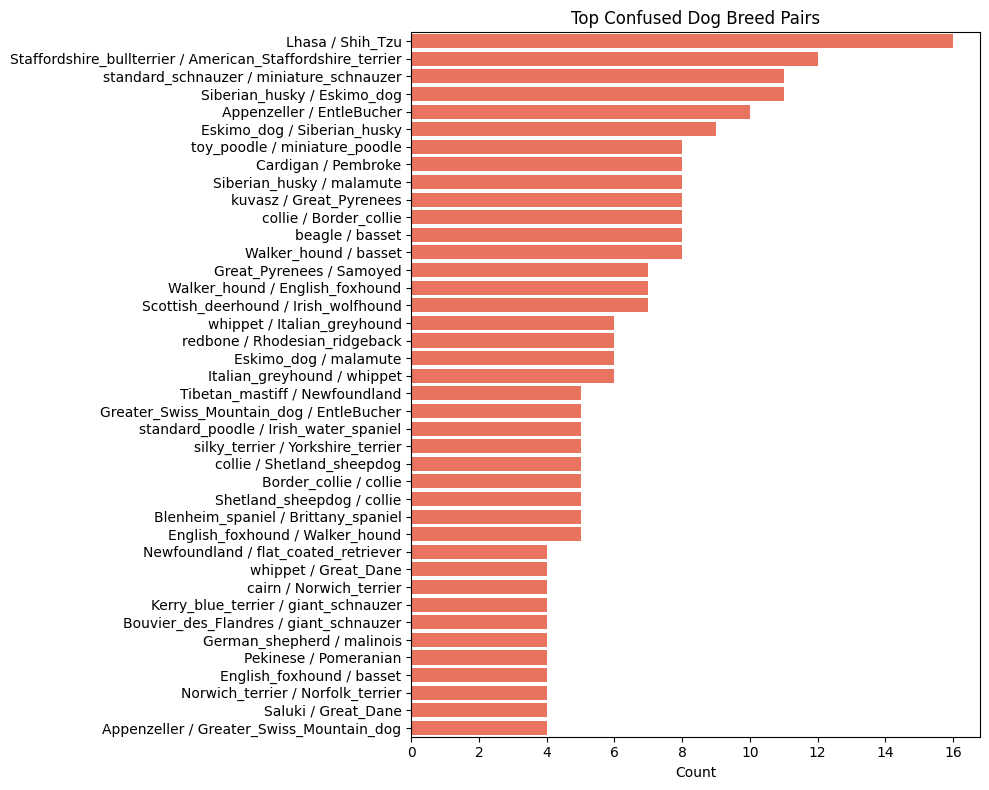

In [15]:
# True and predicted labels
y_true = validation_generator.classes
y_pred = np.argmax(model.predict(validation_generator), axis=1)
class_names = list(validation_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Convert to long format for easier analysis
confused_pairs = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'true_label', 'level_1': 'pred_label', 0: 'count'})
)

# Remove diagonal (correct predictions)
confused_pairs = confused_pairs[confused_pairs['true_label'] != confused_pairs['pred_label']]

# Keep only the most confused pairs
confused_pairs = confused_pairs.sort_values(by='count', ascending=False).head(40)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=confused_pairs,
    y=confused_pairs['true_label'] + ' / ' + confused_pairs['pred_label'],
    x='count',
    color='tomato'
)
plt.title('Top Confused Dog Breed Pairs')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [16]:
#saving model in HDF5 file
model.save("stanford_dogs_mobilenetv2.h5")
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [20]:
#saving model in tensorflow lite 
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("dog_breed_model.tflite", "wb") as f:
    f.write(tflite_model)
print("✅ Exported TensorFlow Lite model!")

INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmpqg4wcvlu\assets


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmpqg4wcvlu\assets


Saved artifact at 'C:\Users\DELL\AppData\Local\Temp\tmpqg4wcvlu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_164')
Output Type:
  TensorSpec(shape=(None, 120), dtype=tf.float32, name=None)
Captures:
  2801555572688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345540624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345540816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2801216797392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345539088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345541008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345541200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345540432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345541584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800345539472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


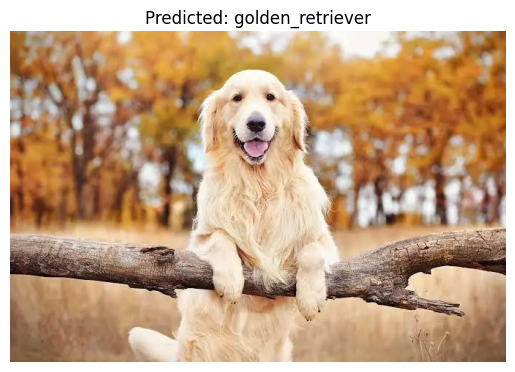

In [18]:
# final testing
def predict_breed(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    breed_name = list(train_generator.class_indices.keys())[predicted_class]

    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {breed_name}")
    plt.show()

# Example usage:
predict_breed("images.jpg")